## Message

In [1]:
# Input cell
TEXT = "29 Cyg b"

Saved: /Users/mloktionov/Projects/IncusLuminis/products/nebulacast/nebulacast-content/content/papers/shared/animations/text/typing_terminal.gif


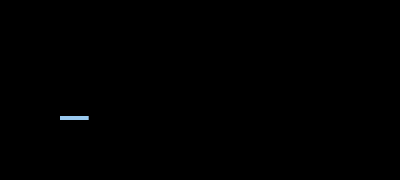

In [5]:
from pathlib import Path
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display, Image as IPyImage

# =========================
# Input fallback
# =========================
if "TEXT" not in globals():
    TEXT = "SYSTEM ONLINE"

# =========================
# Config
# =========================
OUTPUT_DIR = Path.cwd() / "animations" / "text"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_GIF = OUTPUT_DIR / "typing_terminal.gif"

WIDTH = 400
HEIGHT = 180
BG_COLOR = "black"
FG_COLOR = "#99c9ef"

MARGIN_X = 60
MARGIN_Y = 60

FPS = 60
FINAL_CURSOR_BLINKS = 5
CURSOR_CHAR = "_"

# отдельные параметры
FRAME_DURATION_MS = max(10, int(1000 / FPS))
CURSOR_BLINK_MS = 150
FINAL_STILL_MS = 700

FONT_CANDIDATES = [
    "/System/Library/Fonts/Menlo.ttc",
    "/System/Library/Fonts/SFNSMono.ttf",
    "/usr/share/fonts/truetype/dejavu/DejaVuSansMono.ttf",
    "/usr/share/fonts/truetype/liberation2/LiberationMono-Regular.ttf",
    "C:/Windows/Fonts/consola.ttf",
    "C:/Windows/Fonts/lucon.ttf",
]

FONT_SIZE = 48


def load_font(size):
    for path in FONT_CANDIDATES:
        try:
            return ImageFont.truetype(path, size=size)
        except Exception:
            continue
    return ImageFont.load_default()


FONT = load_font(FONT_SIZE)


def get_text_bbox(text, font):
    tmp = Image.new("RGB", (10, 10), "black")
    draw = ImageDraw.Draw(tmp)
    return draw.textbbox((0, 0), text, font=font)


def get_fixed_text_origin(full_text, font):
    bbox = get_text_bbox(full_text + CURSOR_CHAR, font)
    text_h = bbox[3] - bbox[1]

    x = MARGIN_X
    y = max(MARGIN_Y, (HEIGHT - text_h) // 2)

    return x, y


FIXED_X, FIXED_Y = get_fixed_text_origin(TEXT, FONT)


def make_frame(text_to_show, cursor_visible):
    img = Image.new("RGB", (WIDTH, HEIGHT), BG_COLOR)
    draw = ImageDraw.Draw(img)

    full_text = text_to_show + (CURSOR_CHAR if cursor_visible else "")
    draw.text((FIXED_X, FIXED_Y), full_text, font=FONT, fill=FG_COLOR)

    return img


def build_frames(text):
    frames = []
    durations = []
    revealed = ""

    # старт: только курсор
    frames.append(make_frame(revealed, True))
    durations.append(FRAME_DURATION_MS)

    # набор: курсор всегда впереди, без мигания
    for ch in text:
        revealed += ch
        frames.append(make_frame(revealed, True))
        durations.append(FRAME_DURATION_MS)

    # финальное мигание курсора
    for _ in range(FINAL_CURSOR_BLINKS):
        frames.append(make_frame(revealed, True))
        durations.append(CURSOR_BLINK_MS)

        frames.append(make_frame(revealed, False))
        durations.append(CURSOR_BLINK_MS)

    # финальный стоп без курсора
    frames.append(make_frame(revealed, False))
    durations.append(FINAL_STILL_MS)

    return frames, durations


def save_gif(frames, output_path, durations):
    out = Path(output_path).resolve()
    out.parent.mkdir(parents=True, exist_ok=True)
    frames[0].save(
        out,
        save_all=True,
        append_images=frames[1:],
        optimize=False,
        duration=durations,
        loop=0,
    )
    return out


frames, durations = build_frames(TEXT)
gif_path = save_gif(frames, OUTPUT_GIF, durations)

print(f"Saved: {gif_path}")
display(IPyImage(filename=str(gif_path)))

## Big numbers and texts

In [36]:
TARGET_VALUE = "FA254126FB008"

Mode: text
Saved: /Users/mloktionov/PycharmProjects/Stellar_Attractor/ANIM/Papers/shared/animations/text/counter_animation.gif


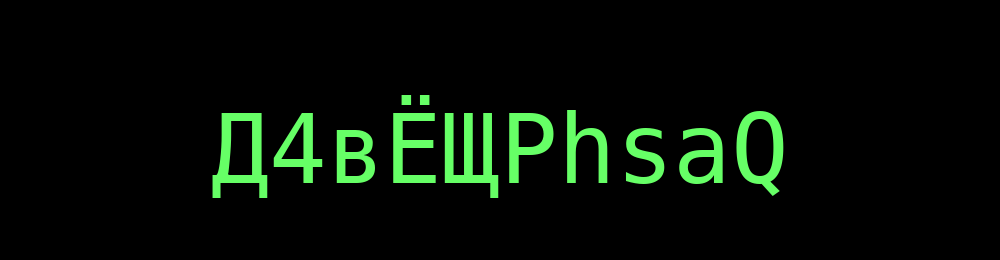

In [6]:
from pathlib import Path
from decimal import Decimal, ROUND_HALF_UP, InvalidOperation
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display, Image as IPyImage
import random
import string

# =========================
# Input fallback
# =========================
if "TARGET_VALUE" not in globals():
    TARGET_VALUE = "HELLO 2025"

# =========================
# Config
# =========================
OUTPUT_DIR = Path.cwd() / "animations" / "text"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_GIF = OUTPUT_DIR / "counter_animation.gif"

WIDTH = 1000
HEIGHT = 260
BG_COLOR = "black"
FG_COLOR = "#66FF66"

FONT_SIZE = 96
MARGIN_X = 60
MARGIN_Y = 60

FPS = 30
ANIMATION_SECONDS = 2.2
FINAL_HOLD_SECONDS = 0.8

NUMBER_FORMAT = "EU"   # "US" | "EU"

EU_GROUPING_SEPARATOR = " "
EU_DECIMAL_SEPARATOR = "."
US_GROUPING_SEPARATOR = ","
US_DECIMAL_SEPARATOR = "."

DECIMAL_PLACES = None
USE_GROUPING = True

TEXT_MODE = "random"  # "random" | "sequential"

FRAME_DURATION_MS = int(1000 / FPS)

FONT_CANDIDATES = [
    "/System/Library/Fonts/Menlo.ttc",
    "/usr/share/fonts/truetype/dejavu/DejaVuSansMono.ttf",
    "C:/Windows/Fonts/consola.ttf",
]

# =========================
# Character sets
# =========================
CYRILLIC_UPPER = "АБВГДЕЁЖЗИЙКЛМНОПРСТУФХЦЧШЩЪЫЬЭЮЯ"
CYRILLIC_LOWER = CYRILLIC_UPPER.lower()

CHARSET = (
    " "
    + string.ascii_uppercase
    + string.ascii_lowercase
    + CYRILLIC_UPPER
    + CYRILLIC_LOWER
    + string.digits
    + ".,:-_/"
)

# =========================
# Font
# =========================
def load_font(size):
    for path in FONT_CANDIDATES:
        try:
            return ImageFont.truetype(path, size=size)
        except Exception:
            continue
    return ImageFont.load_default()


FONT = load_font(FONT_SIZE)

# =========================
# Mode detection
# =========================
def detect_mode(value):
    if isinstance(value, (int, float, Decimal)):
        return "numeric"

    if isinstance(value, str):
        try:
            Decimal(value.strip())
            return "numeric"
        except Exception:
            return "text"

    return "text"


MODE = detect_mode(TARGET_VALUE)

# =========================
# Numeric helpers
# =========================
def to_decimal(value) -> Decimal:
    if isinstance(value, Decimal):
        return value
    if isinstance(value, int):
        return Decimal(value)
    if isinstance(value, float):
        return Decimal(str(value))
    if isinstance(value, str):
        try:
            return Decimal(value.strip())
        except InvalidOperation as e:
            raise ValueError(f"TARGET_VALUE is not a valid numeric string: {value}") from e
    raise TypeError("TARGET_VALUE must be int, float, str, or Decimal.")


def infer_decimal_places(value, override):
    if override is not None:
        if not isinstance(override, int) or override < 0:
            raise ValueError("DECIMAL_PLACES must be None or a non-negative integer.")
        return override

    if isinstance(value, int):
        return 0

    if isinstance(value, str):
        s = value.strip()
        if "." in s:
            return len(s.split(".")[1])
        return 0

    dec = to_decimal(value).normalize()
    exponent = dec.as_tuple().exponent
    return max(0, -exponent)


def to_scaled_int(value, decimal_places: int) -> int:
    dec = to_decimal(value)
    scale = Decimal(10) ** decimal_places
    return int((dec * scale).quantize(Decimal("1"), rounding=ROUND_HALF_UP))


def format_scaled_value(scaled_value: int, decimal_places: int) -> str:
    sign = "-" if scaled_value < 0 else ""
    scaled_value = abs(scaled_value)

    if NUMBER_FORMAT == "US":
        grouping_sep = US_GROUPING_SEPARATOR
        decimal_sep = US_DECIMAL_SEPARATOR
    elif NUMBER_FORMAT == "EU":
        grouping_sep = EU_GROUPING_SEPARATOR
        decimal_sep = EU_DECIMAL_SEPARATOR
    else:
        raise ValueError("NUMBER_FORMAT must be 'US' or 'EU'")

    if decimal_places == 0:
        if USE_GROUPING:
            body = f"{scaled_value:,}".replace(",", grouping_sep)
        else:
            body = str(scaled_value)
        return sign + body

    divisor = 10 ** decimal_places
    integer_part = scaled_value // divisor
    fractional_part = scaled_value % divisor

    if USE_GROUPING:
        int_text = f"{integer_part:,}".replace(",", grouping_sep)
    else:
        int_text = str(integer_part)

    frac_text = str(fractional_part).rjust(decimal_places, "0")
    return f"{sign}{int_text}{decimal_sep}{frac_text}"


def ease_out_cubic(t: float) -> float:
    return 1 - (1 - t) ** 3


def build_value_sequence(target_scaled: int, fps: int, seconds: float) -> list[int]:
    total = max(2, int(round(fps * seconds)))
    out = []

    for i in range(total):
        t = i / (total - 1)
        out.append(int(round(target_scaled * ease_out_cubic(t))))

    out[-1] = target_scaled

    for i in range(1, len(out)):
        if out[i] < out[i - 1]:
            out[i] = out[i - 1]

    return out

# =========================
# Text mode helpers
# =========================

def get_local_charset(ch: str) -> str:
    if ch in string.ascii_lowercase:
        return string.ascii_lowercase
    if ch in string.ascii_uppercase:
        return string.ascii_uppercase
    if ch in CYRILLIC_LOWER:
        return CYRILLIC_LOWER
    if ch in CYRILLIC_UPPER:
        return CYRILLIC_UPPER
    if ch in string.digits:
        return string.digits
    return CHARSET  # fallback

def build_text_sequence_random(target: str, fps: int, seconds: float):
    total = max(2, int(round(fps * seconds)))
    length = len(target)
    frames = []

    for frame in range(total):
        t = frame / (total - 1)
        progress = ease_out_cubic(t)

        current = []
        for i, ch in enumerate(target):
            threshold = (i + 1) / length
            if progress >= threshold:
                current.append(ch)
            else:
                current.append(random.choice(CHARSET))

        frames.append("".join(current))

    frames[-1] = target
    return frames


def build_text_sequence_sequential(target: str, fps: int, seconds: float):
    total = max(2, int(round(fps * seconds)))
    length = len(target)

    current = [" "] * length

    local_charsets = [get_local_charset(c) for c in target]

    positions = [0] * length
    target_idx = [
        cs.index(c) if c in cs else None
        for c, cs in zip(target, local_charsets)
    ]

    delays = [int((i / max(1, length)) * total * 0.6) for i in range(length)]

    frames = []

    for frame in range(total):
        for i in range(length):
            if frame < delays[i]:
                continue

            if target_idx[i] is None:
                current[i] = target[i]
                continue

            cs = local_charsets[i]

            if positions[i] != target_idx[i]:
                positions[i] = (positions[i] + 1) % len(cs)
                current[i] = cs[positions[i]]
            else:
                current[i] = target[i]

        frames.append("".join(current))

    frames[-1] = target
    return frames


def build_text_sequence(target: str, fps: int, seconds: float):
    if TEXT_MODE == "random":
        return build_text_sequence_random(target, fps, seconds)
    if TEXT_MODE == "sequential":
        return build_text_sequence_sequential(target, fps, seconds)
    raise ValueError("TEXT_MODE must be 'random' or 'sequential'")

# =========================
# Render
# =========================
def get_text_bbox(text, font):
    tmp = Image.new("RGB", (10, 10), "black")
    return ImageDraw.Draw(tmp).textbbox((0, 0), text, font=font)


def get_fixed_text_origin(max_text, font):
    bbox = get_text_bbox(max_text, font)
    w = bbox[2] - bbox[0]
    h = bbox[3] - bbox[1]
    return (WIDTH - w) // 2, (HEIGHT - h) // 2


def make_frame(text: str, x: int, y: int):
    img = Image.new("RGB", (WIDTH, HEIGHT), BG_COLOR)
    ImageDraw.Draw(img).text((x, y), text, font=FONT, fill=FG_COLOR)
    return img

# =========================
# Build frames
# =========================
frames = []
durations = []

if MODE == "numeric":
    decimal_places = infer_decimal_places(TARGET_VALUE, DECIMAL_PLACES)
    target_scaled = to_scaled_int(TARGET_VALUE, decimal_places)

    target_text = format_scaled_value(target_scaled, decimal_places)
    fixed_x, fixed_y = get_fixed_text_origin(target_text, FONT)

    values = build_value_sequence(target_scaled, FPS, ANIMATION_SECONDS)

    for v in values:
        text = format_scaled_value(v, decimal_places)
        frames.append(make_frame(text, fixed_x, fixed_y))
        durations.append(FRAME_DURATION_MS)

else:
    target_text = str(TARGET_VALUE)
    fixed_x, fixed_y = get_fixed_text_origin(target_text, FONT)

    texts = build_text_sequence(target_text, FPS, ANIMATION_SECONDS)

    for text in texts:
        frames.append(make_frame(text, fixed_x, fixed_y))
        durations.append(FRAME_DURATION_MS)

# финальная пауза
for _ in range(max(1, int(round(FPS * FINAL_HOLD_SECONDS)))):
    frames.append(make_frame(target_text, fixed_x, fixed_y))
    durations.append(FRAME_DURATION_MS)

# =========================
# Save
# =========================
gif_path = Path(OUTPUT_GIF).resolve()
gif_path.parent.mkdir(parents=True, exist_ok=True)
frames[0].save(
    gif_path,
    save_all=True,
    append_images=frames[1:],
    optimize=False,
    duration=durations,
    loop=0,
)

print(f"Mode: {MODE}")
print(f"Saved: {gif_path}")
display(IPyImage(filename=str(gif_path)))

## American dollars

In [46]:
TARGET_AMOUNT = 12500000000

Saved: /Users/mloktionov/PycharmProjects/Stellar_Attractor/ANIM/Papers/shared/animations/text/counter_usd.gif


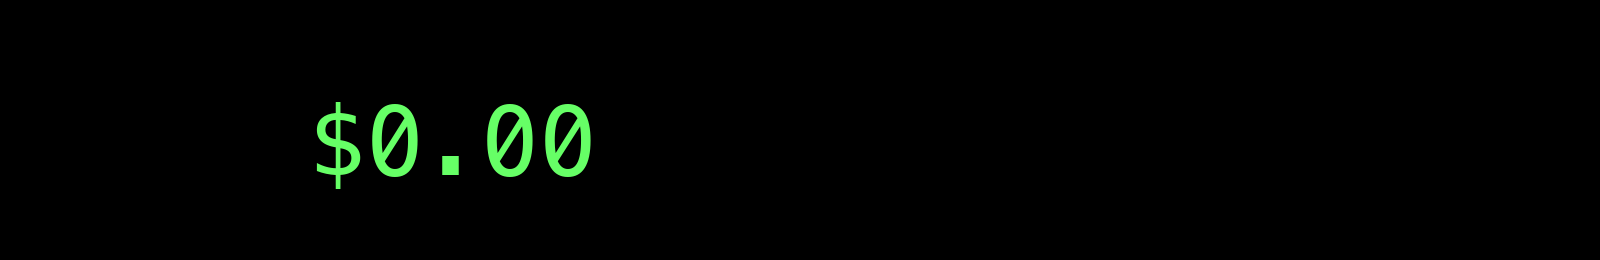

In [7]:
from pathlib import Path
from decimal import Decimal, ROUND_HALF_UP
from PIL import Image, ImageDraw, ImageFont
from IPython.display import display, Image as IPyImage

# =========================
# Input fallback
# =========================
if "TARGET_AMOUNT" not in globals():
    TARGET_AMOUNT = 1234567890.00

# =========================
# Config
# =========================
OUTPUT_DIR = Path.cwd() / "animations" / "text"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_GIF = OUTPUT_DIR / "counter_usd.gif"

WIDTH = 1600
HEIGHT = 260
BG_COLOR = "black"
FG_COLOR = "#66FF66"

FONT_SIZE = 96
MARGIN_X = 60
MARGIN_Y = 60

FPS = 30
ANIMATION_SECONDS = 2.2
FINAL_HOLD_SECONDS = 0.8

FRAME_DURATION_MS = int(1000 / FPS)

FONT_CANDIDATES = [
    "/System/Library/Fonts/Menlo.ttc",
    "/System/Library/Fonts/SFNSMono.ttf",
    "/usr/share/fonts/truetype/dejavu/DejaVuSansMono.ttf",
    "/usr/share/fonts/truetype/liberation2/LiberationMono-Regular.ttf",
    "C:/Windows/Fonts/consola.ttf",
    "C:/Windows/Fonts/lucon.ttf",
]


def load_font(size):
    for path in FONT_CANDIDATES:
        try:
            return ImageFont.truetype(path, size=size)
        except Exception:
            continue
    return ImageFont.load_default()


FONT = load_font(FONT_SIZE)


def to_cents(amount) -> int:
    dec = Decimal(str(amount)).quantize(Decimal("0.01"), rounding=ROUND_HALF_UP)
    return int((dec * 100).to_integral_value(rounding=ROUND_HALF_UP))


def format_usd_from_cents(cents: int) -> str:
    dollars = cents // 100
    cents_part = cents % 100
    return f"${dollars:,}.{cents_part:02d}"


def get_text_bbox(text, font):
    tmp = Image.new("RGB", (10, 10), "black")
    draw = ImageDraw.Draw(tmp)
    return draw.textbbox((0, 0), text, font=font)


def get_fixed_text_origin(max_text, font):
    bbox = get_text_bbox(max_text, font)
    text_w = bbox[2] - bbox[0]
    text_h = bbox[3] - bbox[1]

    x = max(MARGIN_X, (WIDTH - text_w) // 2)
    y = max(MARGIN_Y, (HEIGHT - text_h) // 2)
    return x, y


def ease_out_cubic(t: float) -> float:
    return 1 - (1 - t) ** 3


def build_value_sequence(target_cents: int, fps: int, seconds: float) -> list[int]:
    total_frames = max(2, int(round(fps * seconds)))
    values = []

    for i in range(total_frames):
        t = i / (total_frames - 1)
        progress = ease_out_cubic(t)
        value = int(round(target_cents * progress))
        values.append(value)

    values[-1] = target_cents

    for i in range(1, len(values)):
        if values[i] < values[i - 1]:
            values[i] = values[i - 1]

    return values


def make_frame(text: str, x: int, y: int):
    img = Image.new("RGB", (WIDTH, HEIGHT), BG_COLOR)
    draw = ImageDraw.Draw(img)
    draw.text((x, y), text, font=FONT, fill=FG_COLOR)
    return img


def save_gif(frames, durations_ms, output_path):
    out = Path(output_path).resolve()
    out.parent.mkdir(parents=True, exist_ok=True)
    frames[0].save(
        out,
        save_all=True,
        append_images=frames[1:],
        optimize=False,
        duration=durations_ms,
        loop=0,
    )
    return out


# =========================
# Validation
# =========================
if not isinstance(TARGET_AMOUNT, (int, float, str, Decimal)):
    raise TypeError("TARGET_AMOUNT must be int, float, str, or Decimal.")

target_cents = to_cents(TARGET_AMOUNT)

if target_cents < 0:
    raise ValueError("TARGET_AMOUNT must be >= 0.")


# =========================
# Build frames
# =========================
target_text = format_usd_from_cents(target_cents)
fixed_x, fixed_y = get_fixed_text_origin(target_text, FONT)

values = build_value_sequence(target_cents, FPS, ANIMATION_SECONDS)

frames = []
durations = []

for value_cents in values:
    text = format_usd_from_cents(value_cents)
    frames.append(make_frame(text, fixed_x, fixed_y))
    durations.append(FRAME_DURATION_MS)

final_hold_frames = max(1, int(round(FINAL_HOLD_SECONDS * FPS)))
for _ in range(final_hold_frames):
    frames.append(make_frame(target_text, fixed_x, fixed_y))
    durations.append(FRAME_DURATION_MS)

gif_path = save_gif(frames, durations, OUTPUT_GIF)

print(f"Saved: {gif_path}")
display(IPyImage(filename=str(gif_path)))

In [1]:
from pathlib import Path
import sys
import numpy as np
from PIL import Image, ImageDraw, ImageFont, ImageFilter

TEXT = "SIGNAL DETECTED"
OUT_DIR = Path.cwd() / "animations" / "text"
OUT_DIR.mkdir(parents=True, exist_ok=True)
ANIM_NAME = "blinking_text"
OUTPUT_FORMAT = "webm"  # webm | gif — для HUD зоны type=video лучше webm

W, H = 600, 80
FPS = 24
DURATION_SEC = 4
BLINK_CYCLES = 2
FONT_SIZE = 64
WEBM_CRF = 32

TEXT_COLOR = (90, 230, 255)
BG_COLOR = (0, 0, 0)

# export через vizlib HUD Panel Tracer (ffmpeg VP9)
_HUD_ROOT = Path.cwd().resolve().parent.parent / "Infographics/tools/hud_panel_tracer"
if str(_HUD_ROOT) not in sys.path:
    sys.path.insert(0, str(_HUD_ROOT))
from vizlib.animation_export import export_animation

def load_font(size):
    for path in [
        "/System/Library/Fonts/Menlo.ttc",
        "/Library/Fonts/Arial.ttf",
        "DejaVuSansMono.ttf",
    ]:
        try:
            return ImageFont.truetype(path, size)
        except Exception:
            pass
    return ImageFont.load_default()


def rgba_frames_to_rgb(frames_rgba):
    out = []
    for frame in frames_rgba:
        flat = Image.new("RGBA", frame.size, (*BG_COLOR, 255))
        flat.alpha_composite(frame.convert("RGBA"))
        out.append(np.array(flat.convert("RGB"), dtype=np.uint8))
    return out


font = load_font(FONT_SIZE)
frames = []
total_frames = FPS * DURATION_SEC

for i in range(total_frames):
    phase = 2 * np.pi * BLINK_CYCLES * i / total_frames

    # медленное появление и затухание
    alpha = int(255 * (0.5 + 0.5 * np.sin(phase - np.pi / 2)))

    img = Image.new("RGBA", (W, H), (*BG_COLOR, 255))
    text_layer = Image.new("RGBA", (W, H), (0, 0, 0, 0))
    d = ImageDraw.Draw(text_layer)

    bbox = d.textbbox((0, 0), TEXT, font=font)
    tw = bbox[2] - bbox[0]
    th = bbox[3] - bbox[1]

    x = (W - tw) // 2
    y = (H - th) // 2

    d.text((x, y), TEXT, font=font, fill=(*TEXT_COLOR, alpha))

    glow = text_layer.filter(ImageFilter.GaussianBlur(7))
    img.alpha_composite(glow)
    img.alpha_composite(text_layer)

    frames.append(img)

rgb_frames = rgba_frames_to_rgb(frames)
out_file = export_animation(
    rgb_frames,
    OUT_DIR,
    ANIM_NAME,
    OUTPUT_FORMAT,
    FPS,
    webm_crf=WEBM_CRF,
)
kb = out_file.stat().st_size / 1024
print(f"Created in {OUT_DIR.resolve()}")
print(f"[CREATED] {out_file.resolve()} ({kb:.0f} KB)")
print("HUD: zone type video → 📂 → этот .webm → binding assets/videos/…")

Created 1 animation as gif in /Users/mloktionov/PycharmProjects/Stellar_Attractor/ANIM/Papers/shared/animations/blinking_text
[CREATED] /Users/mloktionov/PycharmProjects/Stellar_Attractor/ANIM/Papers/shared/animations/blinking_text/blinking_text.gif


In [1]:
from pathlib import Path
import numpy as np
from PIL import Image, ImageDraw, ImageFont, ImageFilter

TEXT = """
Оказывается, даже такая, казалось бы, 
«простая» величина, как скорость вращения звезды, — 
это тонкая комбинация эффектов. 
Вращение, турбулентность, инструмент, 
потемнение к краю… 
И если один из этих факторов учесть грубо, 
вся картина чуть-чуть съезжает. 
Чуть-чуть — но систематически."""

OUT_DIR = Path.cwd() / "animations" / "text"
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_PATH = OUT_DIR / "line_reveal_text2.gif"

W, H = 900, 420
FPS = 24
HOLD_SEC = 1.5

FONT_SIZE = 26
LINE_SPACING = 14

LINE_DELAY_SEC = 0.55      # задержка между строками
FADE_DURATION_SEC = 0.65   # плавность появления строки

TEXT_COLOR = (180, 255, 255)
BG_COLOR = (0, 0, 0)
LEFT_PAD = 80

def load_font(size):
    for path in [
        "/System/Library/Fonts/Menlo.ttc",
        "/Library/Fonts/Arial.ttf",
        "DejaVuSansMono.ttf",
    ]:
        try:
            return ImageFont.truetype(path, size)
        except Exception:
            pass
    return ImageFont.load_default()

def smoothstep(t):
    t = max(0.0, min(1.0, t))
    return t * t * (3 - 2 * t)


GIF_COLORS, GIF_LOSSY = 48, 40  # или запустите ячейку blinking_text выше

def save_animated_gif(frames_rgba, out_path, fps, *, colors=GIF_COLORS, lossy=GIF_LOSSY):
    import shutil, subprocess, tempfile
    rgb_frames = [frame.convert("RGBA").convert("RGB") for frame in frames_rgba]
    peak_i = max(range(len(rgb_frames)), key=lambda i: np.array(rgb_frames[i].convert("L"), dtype=np.uint8).max())
    palette_img = rgb_frames[peak_i].quantize(colors=max(2, int(colors)), method=Image.Quantize.MEDIANCUT)
    p_frames = [fr.quantize(palette=palette_img, dither=Image.Dither.FLOYDSTEINBERG) for fr in rgb_frames]
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    with tempfile.TemporaryDirectory() as tmp:
        raw = Path(tmp) / "raw.gif"
        p_frames[0].save(raw, save_all=True, append_images=p_frames[1:], duration=int(1000/fps), loop=0, disposal=2)
        gs = shutil.which("gifsicle")
        if gs and lossy and int(lossy) > 0:
            subprocess.run([gs, "-O3", f"--colors={int(colors)}", f"--lossy={int(lossy)}", str(raw), "-o", str(out_path)], check=True)
        elif gs:
            subprocess.run([gs, "-O3", f"--colors={int(colors)}", str(raw), "-o", str(out_path)], check=True)
        else:
            raw.replace(out_path)


font = load_font(FONT_SIZE)
lines = TEXT.splitlines()

line_height = FONT_SIZE + LINE_SPACING
total_text_h = len(lines) * line_height
start_y = (H - total_text_h) // 2

total_duration = (
    (len(lines) - 1) * LINE_DELAY_SEC
    + FADE_DURATION_SEC
    + HOLD_SEC
)

total_frames = int(total_duration * FPS)
frames = []

for i in range(total_frames):
    t = i / FPS

    img = Image.new("RGBA", (W, H), (*BG_COLOR, 255))
    text_layer = Image.new("RGBA", (W, H), (0, 0, 0, 0))
    d = ImageDraw.Draw(text_layer)

    for idx, line in enumerate(lines):
        line_start = idx * LINE_DELAY_SEC
        local_t = (t - line_start) / FADE_DURATION_SEC
        alpha = int(255 * smoothstep(local_t))

        if alpha <= 0:
            continue

        bbox = d.textbbox((0, 0), line, font=font)
        tw = bbox[2] - bbox[0]

        x = LEFT_PAD
        y = start_y + idx * line_height

        d.text((x, y), line, font=font, fill=(*TEXT_COLOR, alpha))

    glow = text_layer.filter(ImageFilter.GaussianBlur(5))
    img.alpha_composite(glow)
    img.alpha_composite(text_layer)

    frames.append(img)

save_animated_gif(frames, OUT_PATH, FPS)

print(f"Created 1 animation as gif in {OUT_DIR.resolve()}")
print(f"[CREATED] {OUT_PATH.resolve()}")

Created 1 animation as gif in /Users/mloktionov/PycharmProjects/Stellar_Attractor/ANIM/Papers/shared/animations/line_reveal_text
[CREATED] /Users/mloktionov/PycharmProjects/Stellar_Attractor/ANIM/Papers/shared/animations/line_reveal_text/line_reveal_text2.gif
